In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("cleaned_olympics_data.csv")
df

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country,Medal
0,Montreal,1976,Aquatics,Diving,3m springboard,Köhler christa,Female,East Germany,Silver
1,Montreal,1976,Aquatics,Diving,3m springboard,Kosenkov aleksandr,Male,Soviet Union,Bronze
2,Montreal,1976,Aquatics,Diving,3m springboard,Boggs philip george,Male,United States,Gold
3,Montreal,1976,Aquatics,Diving,3m springboard,Cagnotto giorgio franco,Male,Italy,Silver
4,Montreal,1976,Aquatics,Diving,10m platform,Wilson deborah keplar,Female,United States,Bronze
...,...,...,...,...,...,...,...,...,...
15310,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,Guenot christophe,Male,France,Bronze
15311,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,Kvirkelia manuchar,Male,Georgia,Gold
15312,Beijing,2008,Wrestling,Wrestling Gre-R,55 - 60kg,Rahimov vitaliy,Male,Azerbaijan,Silver
15313,Beijing,2008,Wrestling,Wrestling Gre-R,60 - 66kg,Guenot steeve,Male,France,Gold


In [3]:
df.head()

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country,Medal
0,Montreal,1976,Aquatics,Diving,3m springboard,Köhler christa,Female,East Germany,Silver
1,Montreal,1976,Aquatics,Diving,3m springboard,Kosenkov aleksandr,Male,Soviet Union,Bronze
2,Montreal,1976,Aquatics,Diving,3m springboard,Boggs philip george,Male,United States,Gold
3,Montreal,1976,Aquatics,Diving,3m springboard,Cagnotto giorgio franco,Male,Italy,Silver
4,Montreal,1976,Aquatics,Diving,10m platform,Wilson deborah keplar,Female,United States,Bronze


In [4]:
df.tail()

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country,Medal
15310,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,Guenot christophe,Male,France,Bronze
15311,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,Kvirkelia manuchar,Male,Georgia,Gold
15312,Beijing,2008,Wrestling,Wrestling Gre-R,55 - 60kg,Rahimov vitaliy,Male,Azerbaijan,Silver
15313,Beijing,2008,Wrestling,Wrestling Gre-R,60 - 66kg,Guenot steeve,Male,France,Gold
15314,Beijing,2008,Wrestling,Wrestling Gre-R,96 - 120kg,Lopez mijain,Male,Cuba,Gold


In [5]:
df.describe()

,Year
count,15315.000000
mean,1993.621678
std,10.159586
min,1976.000000
25%,1984.000000
50%,1996.000000
75%,2004.000000
max,2008.000000


# Exploratory data analysis (EDA) -

# Total athletes?

In [6]:
df["Athlete"].nunique()

11337

# Total cities?

In [7]:
df["City"].nunique()

9

# Total sports?

In [8]:
df["Sport"].nunique()

28

# Total males and females?

In [9]:
gender=df["Gender"].value_counts()
gender

Gender
Male      9387
Female    5928
Name: count, dtype: int64

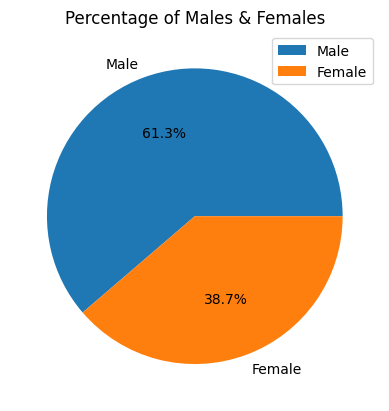

In [10]:
gender.plot(kind='pie',autopct="%1.1f%%")
plt.title("Percentage of Males & Females")
plt.ylabel("")
plt.legend()
plt.show()

# Total medals?

In [11]:
df["Medal"].value_counts()

Medal
Bronze    5258
Gold      5041
Silver    5016
Name: count, dtype: int64

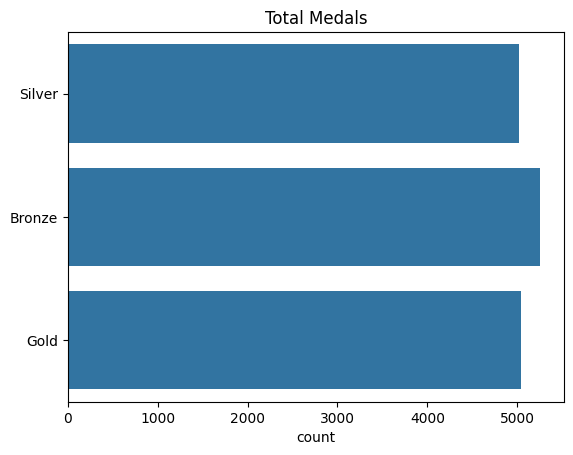

In [12]:
sns.countplot(df["Medal"])
plt.title("Total Medals")
plt.ylabel("")
plt.show()

# Athletes by country?

In [44]:
athletes=df.groupby("Country")["Athlete"].nunique().sort_values(ascending=False).head(10)
athletes

Country
United States     1369
Soviet Union       795
Australia          540
Germany            492
China              486
Russia             474
East Germany       466
South Korea        369
United Kingdom     346
Italy              343
Name: Athlete, dtype: int64

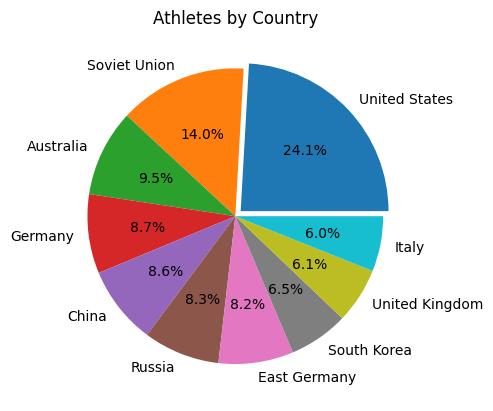

In [50]:
explode=[0.05,0,0,0,0,0,0,0,0,0]
athletes.plot(kind='pie',autopct="%1.1f%%",explode=explode)
plt.title("Athletes by Country")
plt.ylabel("")
plt.show()

# Medals won Over the years?

In [13]:
medal_over_year=df.groupby("Year")["Medal"].count()
medal_over_year

Year
1976    1305
1980    1386
1984    1459
1988    1546
1992    1705
1996    1859
2000    2015
2004    1998
2008    2042
Name: Medal, dtype: int64

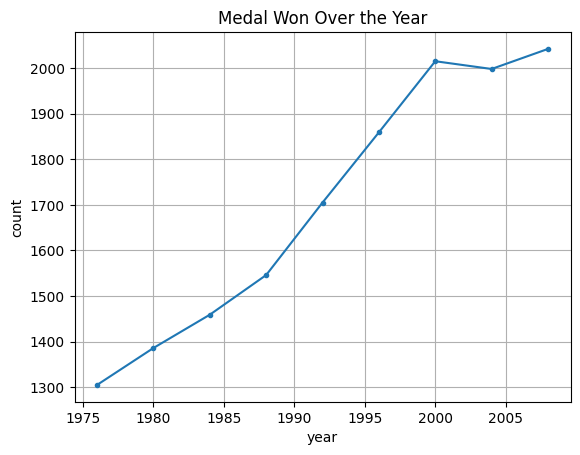

In [14]:
plt.plot(medal_over_year,marker='.')
plt.title("Medal Won Over the Year")
plt.xlabel("year")
plt.ylabel("count")
plt.grid()
plt.show()

# Top athletes with most medals?

In [15]:
athelete_medal=df.groupby("Athlete")["Medal"].count().sort_values(ascending=False)
athelete_medal

Athlete
Phelps michael         16
Thompson jenny         12
Torres dara            12
Andrianov nikolay      12
Fischer birgit         12
                       ..
Cmikiewicz leslaw       1
Zovko zdravko           1
Zozirov zaza            1
Zozulia roman           1
Aarones ann kristin     1
Name: Medal, Length: 11337, dtype: int64

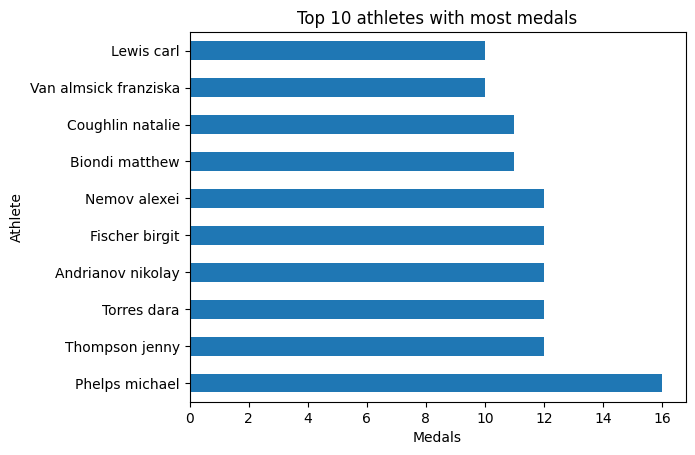

In [16]:
athelete_medal.head(10).plot(kind='barh')
plt.title("Top 10 athletes with most medals")
plt.ylabel("Athlete")
plt.xlabel("Medals")
plt.show()

# medals win by countries?

In [17]:
countries=df.groupby("Country")["Medal"].count().sort_values(ascending=False).head(10)
countries

Country
United States     1992
Soviet Union      1021
Australia          798
Germany            691
China              679
Russia             638
East Germany       626
Italy              486
Romania            482
United Kingdom     467
Name: Medal, dtype: int64

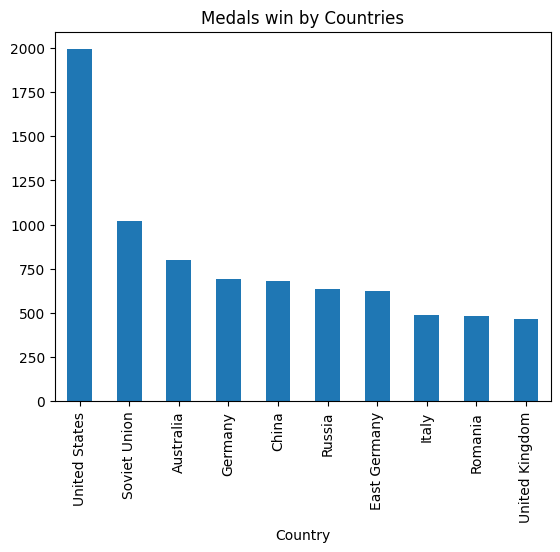

In [18]:
countries.plot(kind='bar')
plt.title("Medals win by Countries")
plt.show()

# Medals by cities?

In [19]:
df.groupby("City")["Medal"].value_counts().sort_values()

City         Medal 
Montreal     Silver    429
             Gold      429
             Bronze    447
Moscow       Silver    455
             Gold      459
             Bronze    472
Los Angeles  Silver    476
             Gold      483
             Bronze    500
Seoul        Silver    505
             Gold      506
             Bronze    535
Barcelona    Silver    551
             Gold      558
             Bronze    596
Atlanta      Silver    610
             Gold      615
             Bronze    634
Athens       Gold      659
             Silver    660
Sydney       Gold      663
Beijing      Silver    663
Sydney       Silver    667
Beijing      Gold      669
Athens       Bronze    679
Sydney       Bronze    685
Beijing      Bronze    710
Name: count, dtype: int64

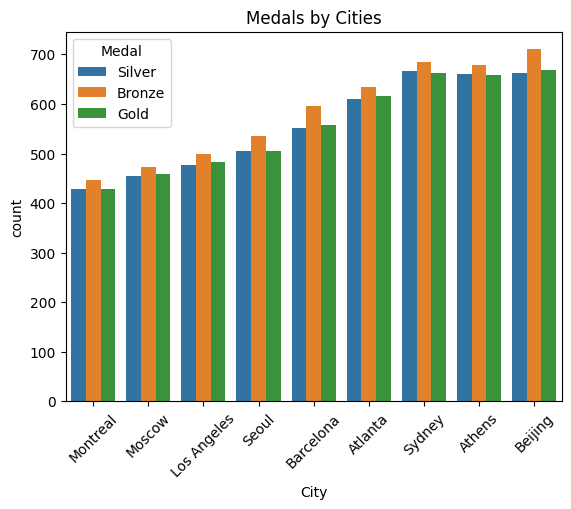

In [20]:
sns.countplot(x=df["City"],hue=df["Medal"])
plt.title("Medals by Cities")
plt.xticks(rotation=45)
plt.show()

# Medals by sports?

In [21]:
medal_by_sports=df.groupby("Medal")["Sport"].value_counts().sort_values(ascending=False)
medal_by_sports

Medal   Sport    
Gold    Aquatics     757
Silver  Aquatics     736
Bronze  Aquatics     717
Silver  Athletics    512
Bronze  Athletics    507
                    ... 
Silver  Taekwondo     24
Gold    Taekwondo     24
Bronze  Triathlon      6
Gold    Triathlon      6
Silver  Triathlon      6
Name: count, Length: 84, dtype: int64

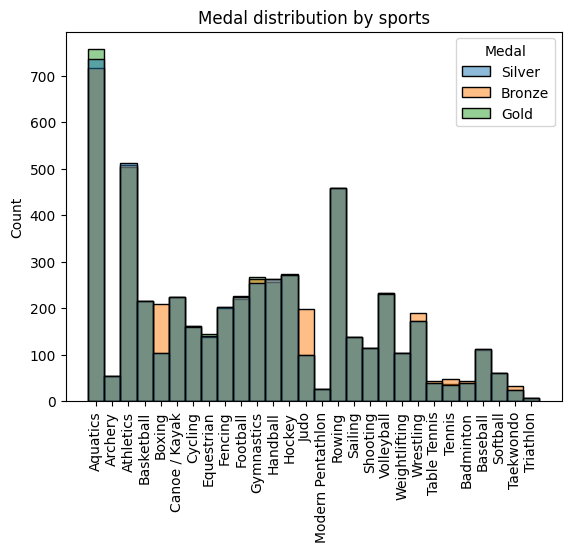

In [22]:
sns.histplot(x=df["Sport"],hue=df["Medal"])
plt.title("Medal distribution by sports")
plt.xlabel("")
plt.xticks(rotation=90)
plt.show()

# Medals by disciplines (games)?

In [25]:
df.groupby("Discipline")["Medal"].count().sort_values(ascending=False)

Discipline
Athletics          1523
Swimming           1422
Rowing             1377
Hockey              816
Handball            780
Artistic G.         672
Football            669
Volleyball          647
Basketball          646
Fencing             606
Canoe / Kayak F     597
Water polo          455
Sailing             417
Boxing              416
Judo                396
Shooting            345
Baseball            335
Cycling Track       322
Weightlifting       311
Wrestling Free.     281
Wrestling Gre-R     252
Diving              180
Softball            180
Archery             162
Synchronized S.     153
Eventing            148
Jumping             140
Dressage            135
Cycling Road        131
Badminton           120
Table Tennis        120
Tennis              118
Rhythmic G.          93
Modern Pentath.      81
Taekwondo            80
Canoe / Kayak S      75
Beach volley.        48
Mountain Bike        24
Triathlon            18
Trampoline           18
BMX                   6
Name:

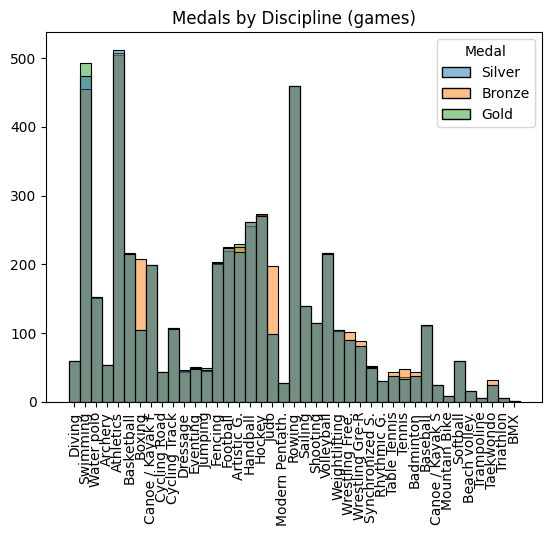

In [26]:
sns.histplot(x=df["Discipline"],hue=df["Medal"])
plt.title("Medals by Discipline (games)")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=90)
plt.show()

In [94]:
df

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country,Medal
0,Montreal,1976,Aquatics,Diving,3m springboard,Köhler christa,Female,East Germany,Silver
1,Montreal,1976,Aquatics,Diving,3m springboard,Kosenkov aleksandr,Male,Soviet Union,Bronze
2,Montreal,1976,Aquatics,Diving,3m springboard,Boggs philip george,Male,United States,Gold
3,Montreal,1976,Aquatics,Diving,3m springboard,Cagnotto giorgio franco,Male,Italy,Silver
4,Montreal,1976,Aquatics,Diving,10m platform,Wilson deborah keplar,Female,United States,Bronze
...,...,...,...,...,...,...,...,...,...
15310,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,Guenot christophe,Male,France,Bronze
15311,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,Kvirkelia manuchar,Male,Georgia,Gold
15312,Beijing,2008,Wrestling,Wrestling Gre-R,55 - 60kg,Rahimov vitaliy,Male,Azerbaijan,Silver
15313,Beijing,2008,Wrestling,Wrestling Gre-R,60 - 66kg,Guenot steeve,Male,France,Gold


# Medal distribution in events?

In [30]:
events=df.groupby("Medal")["Event"].value_counts().sort_values(ascending=False)
events

Medal   Event                           
Bronze  Hockey                              273
Gold    Hockey                              272
Silver  Hockey                              271
Bronze  Handball                            262
Silver  Handball                            262
                                           ... 
Bronze  91 - 110kg, total (heavyweight)       1
        Board (windglider)                    1
Silver  Finn - heavyweight dinghy             1
        Laser - one person dinghy             1
        Laser radial - one person dinghy      1
Name: count, Length: 867, dtype: int64

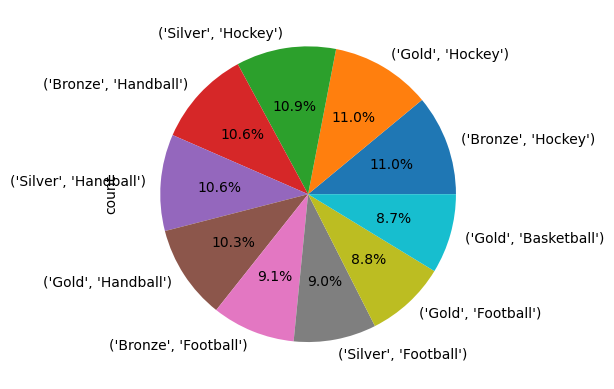

In [31]:
events.head(10).plot(kind='pie',labels=dis1.index,autopct="%1.1f%%")
plt.show()

In [70]:
df

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country,Medal
0,Montreal,1976,Aquatics,Diving,3m springboard,Köhler christa,Female,East Germany,Silver
1,Montreal,1976,Aquatics,Diving,3m springboard,Kosenkov aleksandr,Male,Soviet Union,Bronze
2,Montreal,1976,Aquatics,Diving,3m springboard,Boggs philip george,Male,United States,Gold
3,Montreal,1976,Aquatics,Diving,3m springboard,Cagnotto giorgio franco,Male,Italy,Silver
4,Montreal,1976,Aquatics,Diving,10m platform,Wilson deborah keplar,Female,United States,Bronze
...,...,...,...,...,...,...,...,...,...
15310,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,Guenot christophe,Male,France,Bronze
15311,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,Kvirkelia manuchar,Male,Georgia,Gold
15312,Beijing,2008,Wrestling,Wrestling Gre-R,55 - 60kg,Rahimov vitaliy,Male,Azerbaijan,Silver
15313,Beijing,2008,Wrestling,Wrestling Gre-R,60 - 66kg,Guenot steeve,Male,France,Gold
